# 04 -- Model Evaluation

Final, one-time evaluation of the SELECTED model on the untouched TEST split
(never used for fitting the preprocessor, choosing an imbalance strategy, or
tuning the threshold). Reproduces the same numbers `evaluate.py` writes to
`reports/metrics/test_evaluation.json` and `reports/figures/`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config

cfg = load_config(ROOT / "config.yaml")
pd.set_option("display.max_columns", 40)


In [2]:
from src.data_loader import load_and_split
from src.prediction import load_artifacts
from src import models, evaluation, explainability

model, preprocessor, meta = load_artifacts(cfg)
print("Selected model:", meta["model_type"], "/", meta["strategy"])
print("Threshold:", meta["threshold"], "  source:", meta["threshold_source"])

_, _, test_df = load_and_split(cfg)
y_test = preprocessor.get_target(test_df)

model_type = meta["model_type"]
strategy = meta["strategy"]
use_dense = (model_type in ("logistic_regression", "random_forest")) or (strategy in ("smote", "smote_undersample"))
X_test = preprocessor.transform_dense(test_df) if use_dense else preprocessor.transform_tree(test_df)
X_test = X_test[meta["feature_columns"]]

p_test = models.predict_proba(model, X_test, model_type)
metrics = evaluation.evaluate_scores(y_test, p_test, cfg.evaluation.target_fpr_for_tpr, label="FINAL TEST EVALUATION")

Selected model: lightgbm / none
Threshold: 0.1   source: min expected cost (fp=50, fn=500) on validation


## Confusion matrix and cost-sensitive view at the selected threshold

In [3]:
threshold = float(meta["threshold"])
confusion = evaluation.confusion_at_threshold(y_test, p_test, threshold)
cost = evaluation.cost_sensitive_eval(y_test, p_test, threshold, cfg.evaluation.cost_fp, cfg.evaluation.cost_fn)
print(confusion)
print(cost)

{'threshold': 0.1, 'tn': 146022, 'fp': 2324, 'fn': 1115, 'tp': 539, 'precision': 0.1882640586797066, 'recall': 0.3258766626360339, 'f1': 0.23865397387646667, 'fpr': 0.01566607795289391, 'fnr': 0.6741233373639661}
{'threshold': 0.1, 'tn': 146022, 'fp': 2324, 'fn': 1115, 'tp': 539, 'precision': 0.1882640586797066, 'recall': 0.3258766626360339, 'f1': 0.23865397387646667, 'fpr': 0.01566607795289391, 'fnr': 0.6741233373639661, 'cost_fp': 50, 'cost_fn': 500, 'total_cost': 673700.0, 'cost_per_application': 4.491333333333333}


## Threshold sweep -- finer resolution near the low end (this is a ~1% base rate)

In [4]:
from src.threshold_optimization import sweep_thresholds, sweep_cost_sensitive
f1_sweep = sweep_thresholds(y_test, p_test, cfg.threshold_optimization.thresholds)
display(f1_sweep)

,threshold,tn,fp,fn,tp,precision,recall,f1,fpr,fnr
0,0.01,122368,25978,301,1353,0.049504,0.818017,0.093359,0.175118,0.181983
1,0.02,134283,14063,482,1172,0.076928,0.708585,0.138789,0.094799,0.291415
2,0.03,138852,9494,630,1024,0.097357,0.619105,0.168255,0.063999,0.380895
3,0.05,142829,5517,844,810,0.128023,0.489722,0.202982,0.037190,0.510278
4,0.07,144555,3791,968,686,0.153228,0.414752,0.223781,0.025555,0.585248
5,0.10,146022,2324,1115,539,0.188264,0.325877,0.238654,0.015666,0.674123
6,0.15,147119,1227,1262,392,0.242125,0.237001,0.239536,0.008271,0.762999
7,0.20,147599,747,1366,288,0.278261,0.174123,0.214206,0.005036,0.825877
8,0.25,147881,465,1437,217,0.318182,0.131197,0.185788,0.003135,0.868803
9,0.30,148053,293,1482,172,0.369892,0.103990,0.162341,0.001975,0.896010


## Fairness -- predictive equality, `customer_age > 50` (the BAF paper's protected group)

In [5]:
older = (test_df[cfg.protected_attribute.column] > cfg.protected_attribute.threshold).to_numpy()
fairness = evaluation.fairness_report(y_test, p_test, older, cfg.evaluation.target_fpr_for_tpr, label="customer_age > 50 (test)")

## Feature importance (gain-based) -- only meaningful for the tree models

,feature,gain,share
17,housing_status,50415.660168,0.168979
26,device_os,24384.322859,0.081729
48,risk_x_income,15750.174613,0.052790
39,email_mismatch_free,10890.938402,0.036503
21,has_other_cards,10798.338869,0.036193
1,name_email_similarity,9872.750106,0.033091
3,current_address_months_count,9522.701114,0.031917
27,keep_alive_session,8818.757352,0.029558
5,days_since_request,8427.667933,0.028247
11,velocity_4w,7825.560838,0.026229


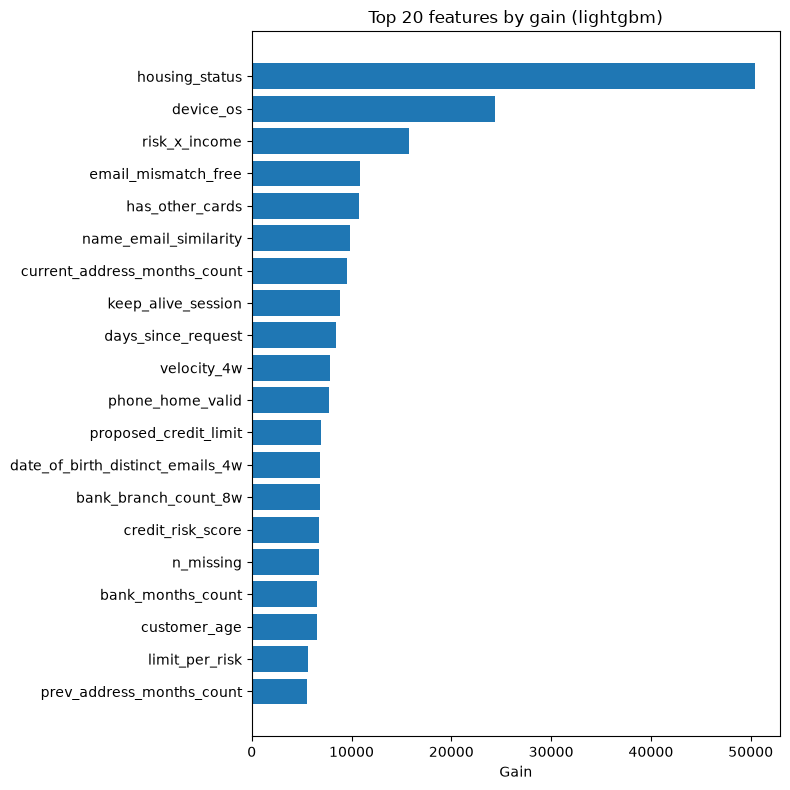

In [6]:
if model_type == "lightgbm":
    imp = explainability.lightgbm_feature_importance(model, top_n=20)
elif model_type == "xgboost":
    imp = explainability.xgboost_feature_importance(model, top_n=20)
else:
    imp = None
    print(f"Selected model is {model_type} -- gain-based importance only applies to tree models.")
if imp is not None:
    display(imp)
    plt.figure(figsize=(8, 8))
    plt.barh(imp["feature"][::-1], imp["gain"][::-1])
    plt.xlabel("Gain")
    plt.title(f"Top 20 features by gain ({model_type})")
    plt.tight_layout()
    plt.show()

## SHAP summary + one real individual fraud-flagged prediction

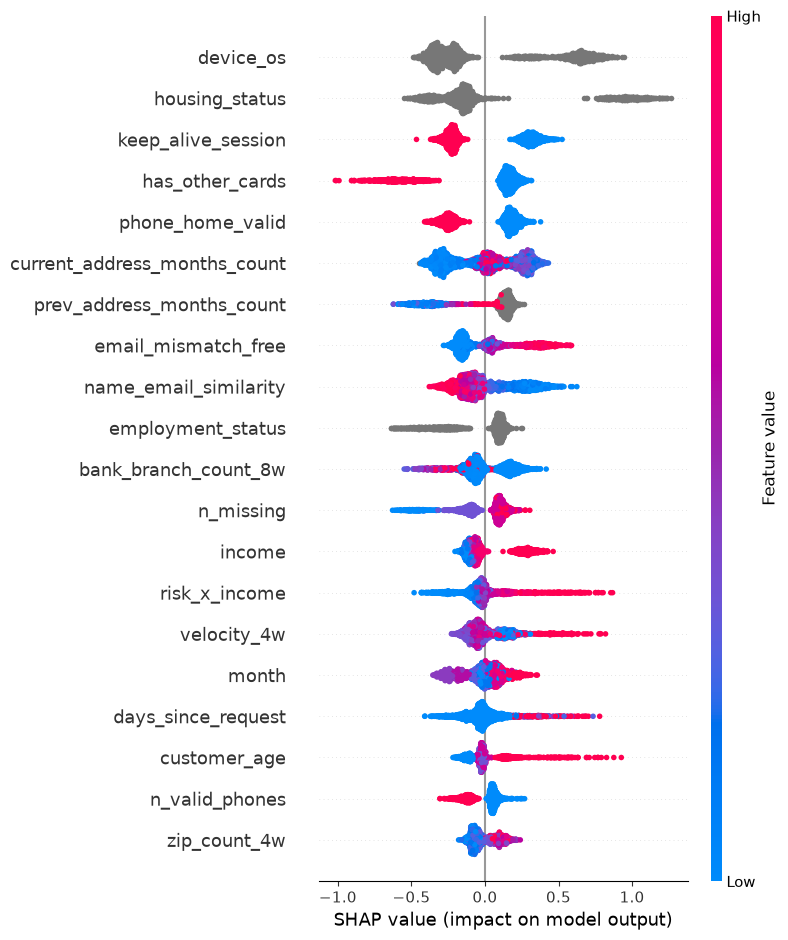

In [7]:
import shap
if model_type in ("lightgbm", "xgboost"):
    rng = np.random.default_rng(cfg.seed)
    sample_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
    X_sample = X_test.iloc[sample_idx]
    explainer, shap_values = explainability.shap_summary(model, X_sample, model_type)
    shap.summary_plot(shap_values, X_sample, max_display=20)
else:
    print(f"Selected model is {model_type} -- shap.TreeExplainer only applies to tree models.")

Real TEST-set fraud-flagged row, index=133783, predicted prob=0.4242


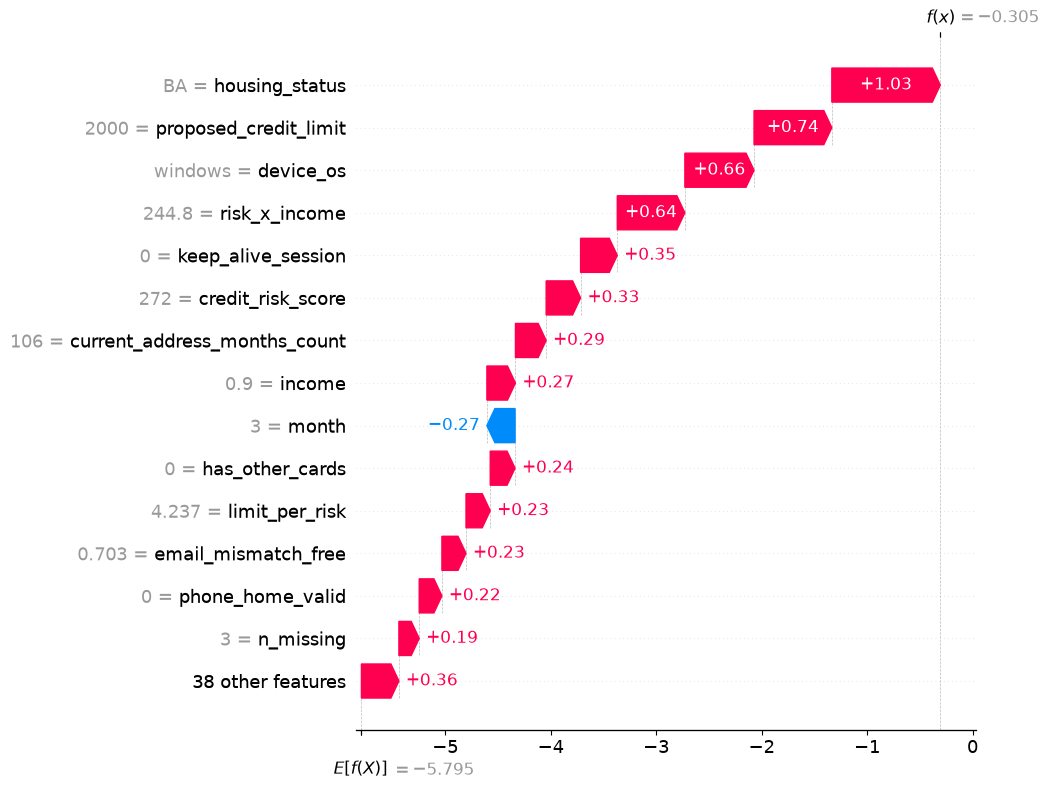

In [8]:
if model_type in ("lightgbm", "xgboost"):
    flagged = np.flatnonzero((p_test[sample_idx] >= threshold) & (y_test.iloc[sample_idx].to_numpy() == 1))
    if len(flagged) > 0:
        pick = sample_idx[flagged[0]]
        row = X_test.iloc[[pick]]
        row_shap = explainability.explain_single_prediction(explainer, row)
        print(f"Real TEST-set fraud-flagged row, index={pick}, predicted prob={p_test[pick]:.4f}")
        shap.plots.waterfall(row_shap[0], max_display=15)
    else:
        print("No true-positive fraud rows landed in this sample; re-run with a larger sample size.")